# Notebook 00 · Sensor Preprocessing

**Goal:** Extract, clean, and temperature-compensate raw on-site sensor data.

**Steps:**
1. **File Inspection** — Examine one raw file before loading to confirm delimiter and column layout.
2. **Data Loading** — Read all raw sensor files from `/data/raw/sensor/`.
3. **Signal Cleaning and Compensation** — Remove power-loss rows, filter physical outliers,
   and apply the on-board temperature compensation coefficient.
4. **Compensation Visualisation** — Plot raw vs. compensated signal and the applied correction.
5. **Save** — Export cleaned, standardized datasets to `/data/interim/sensor/`.

## Import libraries

In [2]:
import sys
import os
import glob
sys.path.insert(0, os.path.abspath('..'))

from heritageshm.dataloader import inspect_raw_file, load_sensor_directory, organize_sensor_data
from heritageshm.preprocessing import process_station
from heritageshm.viz import apply_theme, plot_compensation_comparison

apply_theme(context='notebook')

## Step 1 · File Inspection

Inspect one representative raw file to confirm the delimiter, column count, and date format
before loading the entire directory.

In [3]:
RAW_FOLDER   = 'data/raw/sensor'
FILE_EXT     = '.adc'

sample_files = glob.glob(os.path.join(RAW_FOLDER, f'*{FILE_EXT}'))
if sample_files:
    file_info = inspect_raw_file(sample_files[0])
else:
    print(f'No {FILE_EXT} files found in {RAW_FOLDER}. Check RAW_FOLDER and FILE_EXT.')
    file_info = {}

────────────────────────────────────────────────────────────
  FILE INSPECTION: GUBBIO_20180726.adc
────────────────────────────────────────────────────────────

  DETECTED STRUCTURE
  Delimiter             : 'TAB'
  Decimal symbol        : comma  ','  (European format — decimal_comma=True)
  Column count          : 14
  Header row            : None (header=None)
  Date format hint      : DD/MM/YY  (dayfirst=True)

  SUGGESTED CONFIGURATION
  SEPARATOR           = '\t'
  DECIMAL_COMMA       = True
  HEADER              = None
  # Expected columns  : 14

  FIRST 5 LINES (raw)
  ────────────────────────────────────────────────────────
  25/07/18	23:40:00	3,500	21,965	44,910	1942,625	3,490	21,750	45,115	2122,750	0,000	0,000	0,000	0,000
  26/07/18	00:00:00	3,500	21,695	45,220	1940,625	3,470	21,555	45,155	2122,125	3,480	20,870	50,095	2077,125
  26/07/18	00:20:00	0,000	0,000	0,000	0,000	3,470	21,365	45,040	2121,000	3,490	20,700	48,595	2076,625
  26/07/18	00:40:00	3,490	21,090	45,005	1936,125

## Step 2 · Load Raw Sensor Files

Read all files in the raw sensor directory and organise them into per-station DataFrames.

In [5]:
SEPARATOR = '\t'
DECIMAL_COMMA = True
HEADER = None

STATIONS = {
    'st01': ['charge', 'temp', 'hum', 'absinc'],
    'st02': ['charge', 'temp', 'hum', 'absinc'],
    'st03': ['charge', 'temp', 'hum', 'absinc'],
}



df_raw = load_sensor_directory(
    folder_path=RAW_FOLDER,
    extension=FILE_EXT,
    sep=SEPARATOR,
    header=HEADER,
    column_names=None,
    date_col=0,
    time_col=1,
    save_combined=False,
)

print(f'\nLoaded dataset shape : {df_raw.shape}')
print(f'Date range : {df_raw.index.min()} → {df_raw.index.max()}')

stations_dict = organize_sensor_data(df_raw, STATIONS)
print(f'Organised {len(stations_dict)} station(s): {list(stations_dict.keys())}')

Found 1911 files matching '.adc'. Processing...


Loading sensor data:   0%|          | 0/1911 [00:00<?, ?it/s]

Loading sensor data: 100%|██████████| 1911/1911 [00:54<00:00, 34.78it/s]


Loaded dataset shape : (132590, 12)
Date range : 2018-07-25 23:40:00 → 2025-02-05 12:20:00
Organised 3 station(s): ['st01', 'st02', 'st03']


## Step 3 · Signal Cleaning and Temperature Compensation

For each station, `process_station()` executes three operations in sequence:
1. Removes rows where battery charge equals zero (power-loss events).
2. Drops readings outside the physical validity range defined in `OUTLIER_THRESHOLDS`.
3. Applies linear temperature compensation using `COMP_COEFF`.
   The raw signal is preserved as `{SIGNAL_COL}_raw` in the saved CSV to support
   later visualisation; only the compensated column is returned to the pipeline.

In [ ]:
SIGNAL_COL       = 'absinc'
TEMP_COL         = 'temp'
COMP_COEFF       = 0.005      # mdeg · °C⁻¹ · 10⁻³ — update from calibration sheet
SPIKE_THRESHOLD  = 500.0       # mdeg — maximum allowed |Δ absinc| between samples
OUTPUT_DIR       = 'data/interim/sensor'


processed = {}

for st, df_st in stations_dict.items():
    df_clean, _ = process_station(
        st=st,
        df_st=df_st,
        signal_col=SIGNAL_COL,
        temp_col=TEMP_COL,
        comp_coeff=COMP_COEFF,
        spike_threshold=SPIKE_THRESHOLD,
        output_dir=OUTPUT_DIR,
    )
    processed[st] = df_clean


──────────────────────────────────────────────────
  Station: st01  |  raw rows: 132590
──────────────────────────────────────────────────
  Dropped    1369 spike rows  (|Δabsinc| > 500.0)
  Dropped   47481 power-loss rows (zero charge in 'charge')
  Retained   83740 / 132590 rows (63.2 %)
  Saved → data/interim/sensor\st01_preprocessed.csv
  Shape  : (83740, 5)  |  2018-07-25 23:40:00 → 2022-09-22 17:40:00

──────────────────────────────────────────────────
  Station: st02  |  raw rows: 132590
──────────────────────────────────────────────────
  Dropped    1334 spike rows  (|Δabsinc| > 500.0)
  Dropped   15361 power-loss rows (zero charge in 'charge')
  Retained  115895 / 132590 rows (87.4 %)
  Saved → data/interim/sensor\st02_preprocessed.csv
  Shape  : (115895, 5)  |  2018-07-25 23:40:00 → 2025-02-05 12:20:00

──────────────────────────────────────────────────
  Station: st03  |  raw rows: 132590
──────────────────────────────────────────────────
  Dropped     848 spike rows  (|Δab

## Step 4 · Compensation Visualisation

`plot_compensation_comparison()` reads directly from the saved interim CSV so it can be
called independently at any time — including outside this notebook — to inspect any station.
Modify `VIZ_STATION` (or `viz_file` and `viz_col` below) to inspect a different station or column.

Plot saved successfully to outputs/figures as 00_compensation_comparison


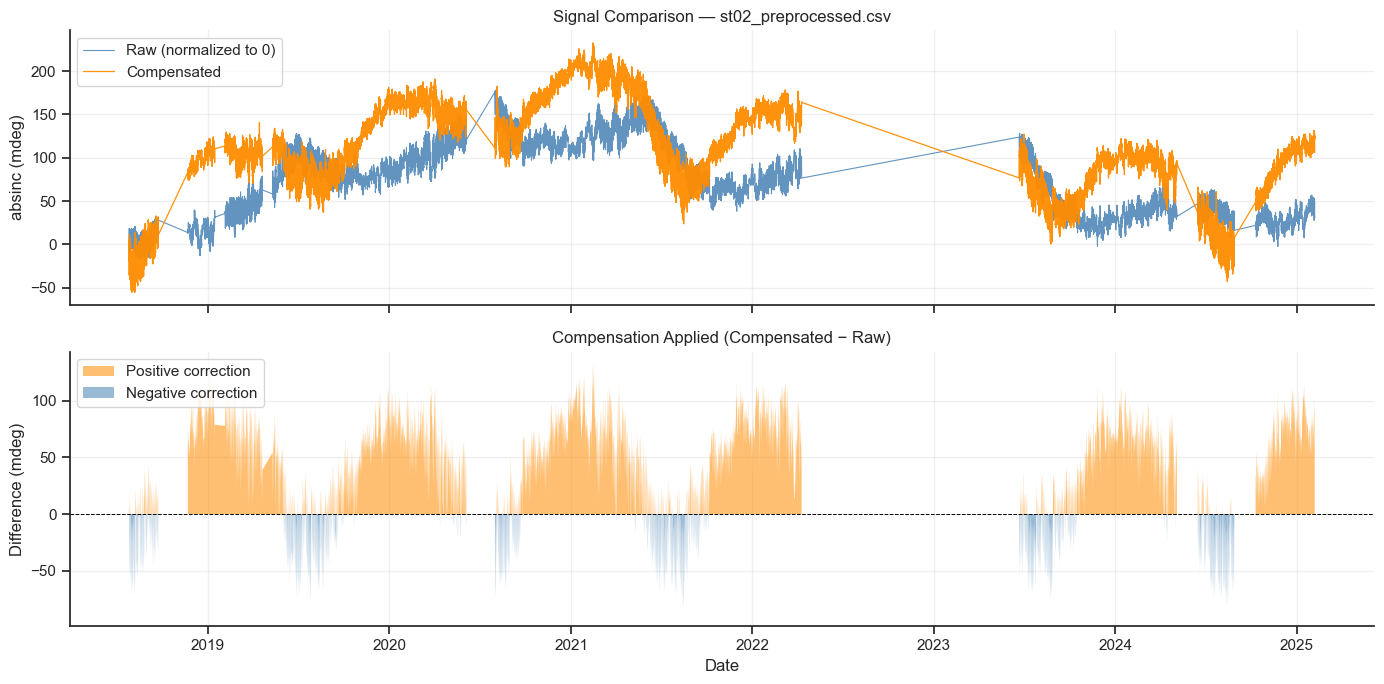

In [9]:
VIZ_STATION = 'st02'
viz_file    = os.path.join(OUTPUT_DIR, f'{VIZ_STATION}_preprocessed.csv')
viz_col     = SIGNAL_COL   # column to plot; change here if a different signal is needed

plot_compensation_comparison(
    file_path=viz_file,
    signal_col=viz_col,
    save_plot=True,
    save_path='outputs/figures',
    filename='00_compensation_comparison',
)

## Step 5 · Dataset Preview

Quick sanity check on the cleaned output for each station.

In [8]:
from IPython.display import display
for st, df_clean in processed.items():
    print(f'--- {st} ---  shape: {df_clean.shape}  |  '
          f'{df_clean.index.min()} → {df_clean.index.max()}')
    display(df_clean.head(3))
    print()

--- st01 ---  shape: (83740, 4)  |  2018-07-25 23:40:00 → 2022-09-22 17:40:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-25 23:40:00,3.5,21.965,44.910,1942.625
2018-07-26 00:00:00,3.5,21.695,45.220,1941.975
2018-07-26 01:00:00,3.5,20.760,45.405,1940.650



--- st02 ---  shape: (115895, 4)  |  2018-07-25 23:40:00 → 2025-02-05 12:20:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-25 23:40:00,3.49,21.750,45.115,2122.750
2018-07-26 00:00:00,3.47,21.555,45.155,2123.100
2018-07-26 00:20:00,3.47,21.365,45.040,2122.925



--- st03 ---  shape: (69967, 4)  |  2018-07-26 00:20:00 → 2023-06-24 16:00:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-26 00:20:00,3.49,20.70,48.595,2076.625
2018-07-26 00:40:00,3.48,20.51,49.005,2076.325
2018-07-26 01:00:00,3.48,20.45,49.120,2076.625
